In [5]:
import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

# 1) Load data
df = pd.read_csv("../Capstone/Capstone Dataset (New).csv")

X = df.drop(
    ["Array type", "Predicted angular insertion depth (deg)",
     "Actual angular insertion depth (deg)"],
    axis=1
)
y = df["Actual angular insertion depth (deg)"]

# This prevents errors.
X = X.select_dtypes(include=[np.number])

# Define model and search space
svr_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVR())
])

param_grid = {
    # Core SVR hyperparameters
    "model__kernel": ["rbf", "linear", "poly"],
    "model__C": [0.1, 1, 10, 100, 300],
    "model__epsilon": [0.01, 0.05, 0.1, 0.2, 0.5],
    # Only used for rbf/poly; safely ignored by linear
    "model__gamma": ["scale", "auto"],
    # Only used for poly; safely ignored by others
    "model__degree": [2, 3]
}

# Grid search
gs = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,                   # change to LeaveOneOut() if dataset is very small
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs.fit(X, y)

print("Best params:", gs.best_params_)
print("CV best MAE:", -gs.best_score_)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
Best params: {'model__C': 100, 'model__degree': 2, 'model__epsilon': 0.5, 'model__gamma': 'scale', 'model__kernel': 'linear'}
CV best MAE: 38.82025608225241


In [6]:
import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error

# Loading dataset
df = pd.read_csv("Capstone Dataset (New).csv")

# Separated features (X) and target (y)
X = df.drop(
    ["Array type", "Predicted angular insertion depth (deg)",
     "Actual angular insertion depth (deg)"],
    axis=1
)
y = df["Actual angular insertion depth (deg)"]

# Ensured numeric features only for scaling/SVR
X = X.select_dtypes(include=[np.number])

# Leave-One-Out CV
loo = LeaveOneOut()

y_true_all = []
y_pred_all = []

# SVR with the best params 
svr_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVR(
        kernel="linear",   # from best params
        C=100,             # from best params
        epsilon=0.5,       # from best params
        gamma="scale",     # ignored for linear kernel
        degree=2           # ignored for linear kernel
    ))
])

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit on training fold
    svr_pipeline.fit(X_train, y_train)

    # Predict the held-out sample
    y_pred = svr_pipeline.predict(X_test)[0]

    # Collect predictions and truth
    y_pred_all.append(y_pred)
    y_true_all.append(y_test.values[0])

# Evaluation (overall MAE across all LOO folds)
mae = mean_absolute_error(y_true_all, y_pred_all)
print("MAE (LOO):", mae)

print("Params used:", {
    "model__kernel": "linear",
    "model__C": 100,
    "model__epsilon": 0.5,
    "model__gamma": "scale",
    "model__degree": 2
})
# Prior GridSearch CV best MAE (for reference): 38.82025608225241


MAE (LOO): 30.195243373875506
Params used: {'model__kernel': 'linear', 'model__C': 100, 'model__epsilon': 0.5, 'model__gamma': 'scale', 'model__degree': 2}


In [7]:
import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import LeaveOneOut, KFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error

# --- Load ---
df = pd.read_csv("Capstone Dataset (New).csv")

# Separate features (X) and target (y)
X = df.drop(
    ["Array type", "Predicted angular insertion depth (deg)",
     "Actual angular insertion depth (deg)"],
    axis=1
)
y = df["Actual angular insertion depth (deg)"].astype(float)

# Numeric-only features
X = X.select_dtypes(include=[np.number]).copy()

# --- Outer CV (LOO) ---
loo = LeaveOneOut()

y_true_all, y_pred_all = [], []
best_params_per_fold = []

n_features = X.shape[1]
# sensible k values for SelectKBest given your feature count
k_options = sorted(set([min(k, n_features) for k in [5, 8, 12, 16, n_features]]))

# Base pipeline: impute -> robust scale -> selectK -> SVR(RBF)
base_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", RobustScaler()),
    ("select", SelectKBest(score_func=f_regression, k=n_features)),  # k tuned below
    ("model", SVR(kernel="rbf"))
])

# Inner CV for tuning
inner_cv = KFold(n_splits=min(5, max(3, len(X) // 5)), shuffle=True, random_state=42)

param_grid = {
    "select__k": k_options,              # feature count
    "model__C": [1, 3, 10, 30, 100, 300],
    "model__epsilon": [0.1, 0.2, 0.5, 1.0],
    "model__gamma": ["scale", "auto", 0.01, 0.03, 0.1, 0.3]
}

# Wrap in TTR so y is standardized during training (inverse transformed on predict)
tuned_reg = GridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=inner_cv,
    n_jobs=-1,
    refit=True
)

reg = TransformedTargetRegressor(
    regressor=tuned_reg,
    transformer=StandardScaler()
)

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)[0]

    y_true_all.append(y_test)
    y_pred_all.append(y_pred)

    # store tuned params for inspection
    best_params_per_fold.append(reg.regressor_.best_params_)

mae = mean_absolute_error(y_true_all, y_pred_all)
print(f"MAE (LOO, RBF-SVR with nested CV): {mae:.4f}")

# (Optional) peek at most frequent best params
from collections import Counter
print("Most common best params over folds:")
for key in ["select__k", "model__C", "model__epsilon", "model__gamma"]:
    cnt = Counter(p[key] for p in best_params_per_fold)
    print(f"  {key}: {cnt.most_common(3)}")


C:\Users\shell\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\shell\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\shell\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\shell\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\shell\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\shell\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\s

MAE (LOO, RBF-SVR with nested CV): 31.8454
Most common best params over folds:
  select__k: [(6, 86)]
  model__C: [(30, 59), (100, 19), (300, 7)]
  model__epsilon: [(0.1, 50), (0.2, 28), (0.5, 8)]
  model__gamma: [(0.01, 85), (0.03, 1)]


C:\Users\shell\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [9]:
import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error

# Loading dataset
df = pd.read_csv("Capstone Dataset (New).csv")

# Separate features (X) and target (y)
X = df.drop(
    ["Array type", "Predicted angular insertion depth (deg)",
     "Actual angular insertion depth (deg)"],
    axis=1
)
y = df["Actual angular insertion depth (deg)"]

# Ensure numeric features only for scaling/SVR
X = X.select_dtypes(include=[np.number])

# Leave-One-Out CV
loo = LeaveOneOut()

y_true_all = []
y_pred_all = []
array_type_all = []


# SVR with my best params 
svr_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVR(
        kernel="rbf",   # from best params
        C=1000,             # from best params
        epsilon=0.5,       # from best params
        gamma=0.01,     # ignored for linear kernel
        degree=2           # ignored for linear kernel
    ))
])

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit on training fold
    svr_pipeline.fit(X_train, y_train)

    # Predict the held-out sample
    y_pred = svr_pipeline.predict(X_test)[0]

    # Collect predictions and truth
    y_pred_all.append(y_pred)
    y_true_all.append(y_test.iloc[0])
    array_type_all.append(df.iloc[test_index[0]]["Array type"])

array_type = np.array(array_type_all)

# Evaluation (overall MAE across all LOO folds)
mae = mean_absolute_error(y_true_all, y_pred_all)
print("MAE (LOO):", mae)

print("Params used:", {
    "model__kernel": "linear",
    "model__C": 100,
    "model__epsilon": 0.5,
    "model__gamma": "scale",
    "model__degree": 2
})

MAE (LOO): 27.21877360910523
Params used: {'model__kernel': 'linear', 'model__C': 100, 'model__epsilon': 0.5, 'model__gamma': 'scale', 'model__degree': 2}


In [16]:
print(y_pred_all)

[368.1124555911043, 467.57953070564895, 457.8503617515146, 366.9862217130343, 361.90230190749116, 383.1925542331679, 338.6505356231763, 443.16595215327163, 399.14848408890055, 354.8510465301039, 349.1369454611074, 403.2305382942643, 362.4806765289404, 366.24785110514176, 322.58809237140133, 399.79105696353747, 435.5844944964208, 528.232175652032, 570.9064932770214, 535.7053019887455, 517.3498598604922, 488.690673542926, 499.2137444823701, 545.462265027508, 555.2484411008995, 494.34510101416095, 587.0135621606572, 597.9959063395829, 540.730370439819, 492.37154983359244, 656.2033588435165, 534.2915644099878, 582.7564037443445, 532.5756892228014, 507.59908606802594, 550.3187858635029, 576.1480216082867, 455.0724258486498, 425.69795618091007, 423.07234752108684, 443.3814102138318, 477.6524642706528, 473.50682289397605, 542.067780954728, 432.68744715239893, 456.55815945525467, 540.7858424941167, 572.2280501487381, 430.9384239696717, 362.2958216917352, 397.61221984263875, 332.2584022711877, 

In [17]:
print(y_true_all)

[342, 473, 413, 371, 404, 385, 328, 422, 389, 363, 352, 395, 357, 409, 359, 422, 461, 581, 637, 489, 513, 449, 465, 545, 584, 454, 637, 600, 537, 500, 717, 516, 510, 483, 584, 523, 513, 502, 416, 394, 478, 474, 527, 554, 426, 458, 603, 581, 472, 366, 398, 357, 480, 422, 419, 376, 374, 336, 467, 432, 443, 450, 391, 311, 398, 402, 538, 406, 487, 416, 365, 394, 340, 431, 374, 394, 417, 455, 388, 475, 371, 637, 661, 584, 584, 447]


In [10]:
import numpy as np

pred = np.array(y_pred_all)
true = np.array(y_true_all)
array_type = np.array(array_type_all)

differences = pred - true
absolute_diff = np.abs(differences)

# --- FILTERS ---
absolute_diff_flex24 = absolute_diff[array_type == "Flex24"]
absolute_diff_flex28 = absolute_diff[array_type == "Flex28"]
absolute_diff_flex = absolute_diff[array_type == "MED-EL FLex"]

print("Done filtering.")

Done filtering.


In [11]:
#Converting the lists into arrays
import numpy as np

pred = np.array(y_pred_all)
true = np.array(y_true_all)

differences = pred - true
absolute_diff = np.absolute(differences)
standarddev = np.std(differences, ddof =1)

print("Differences: ", differences)
print("Standard Deviation: ", standarddev)
print("Absolute Difference: ", absolute_diff)

Differences:  [  26.11245559   -5.42046929   44.85036175   -4.01377829  -42.09769809
   -1.80744577   10.65053562   21.16595215   10.14848409   -8.14895347
   -2.86305454    8.23053829    5.48067653  -42.75214889  -36.41190763
  -22.20894304  -25.4155055   -52.76782435  -66.09350672   46.70530199
    4.34985986   39.69067354   34.21374448    0.46226503  -28.7515589
   40.34510101  -49.98643784   -2.00409366    3.73037044   -7.62845017
  -60.79664116   18.29156441   72.75640374   49.57568922  -76.40091393
   27.31878586   63.14802161  -46.92757415    9.69795618   29.07234752
  -34.61858979    3.65246427  -53.49317711  -11.93221905    6.68744715
   -1.44184054  -62.21415751   -8.77194985  -41.06157603   -3.70417831
   -0.38778016  -24.74159773  -20.31943948   10.03685163   60.20976011
    3.38630257   18.96327643   14.49682664   -5.44394277    1.12190807
  -52.31729998    0.918845    -15.31100051   28.96550946 -102.35695749
   43.21178461  -80.40285409    6.77294383  -17.87672045  -26.84

In [12]:
#Instead of calculating the standard deviation for differences, calculate for the absolute difference

stddev = np.std(absolute_diff, ddof = 1)

print("The Standard Deviation of the Absolute Differences is: ", stddev)

The Standard Deviation of the Absolute Differences is:  24.619687810988953


In [ ]:
#Start on writing the paper, try to follow the struture: title, abstract, introduction, and move forward later on.

In [ ]:
#import matplotlib.pyplot as plt

#plt.figure()

#plt.boxplot(absolute_diff)

#plt.ylabel("Absolute Insertion Depth Error [°]")
#plt.xlabel("Flex (Overall)")

#plt.show()

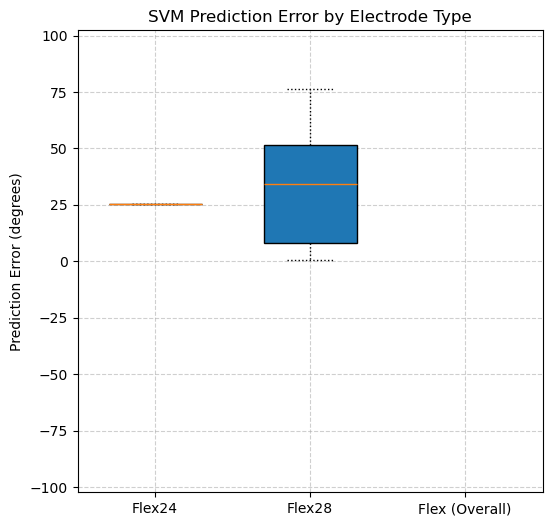

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# --- Filter by electrode type ---
absolute_diff_flex24 = absolute_diff[array_type == "Flex24"]
absolute_diff_flex28 = absolute_diff[array_type == "Flex28"]
absolute_diff_flex = absolute_diff[array_type == "MED-EL FLex"]

# --- Combine data ---
data = [absolute_diff_flex24, absolute_diff_flex28, absolute_diff_flex]
labels = ["Flex24", "Flex28", "Flex (Overall)"]

# --- Plot ---
plt.figure(figsize=(6,6))

box = plt.boxplot(
    data,
    widths=0.6,
    patch_artist=True
)

# Remove the weird "1" and set proper labels
plt.xticks([1, 2, 3], labels)

# Dotted whiskers to match other figures
for whisker in box['whiskers']:
    whisker.set_linestyle(':')

for cap in box['caps']:
    cap.set_linestyle(':')

# Symmetric y-axis (adds negative side)
max_val = np.max(np.abs(absolute_diff))
plt.ylim(-max_val, max_val)

# Labels and title
plt.ylabel("Prediction Error (degrees)")
plt.title("SVM Prediction Error by Electrode Type")

# Grid styling to match typical academic figures
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [22]:
print(len(y_pred_all))
print(len(y_true_all))
print(len(array_type_all))

86
86
86


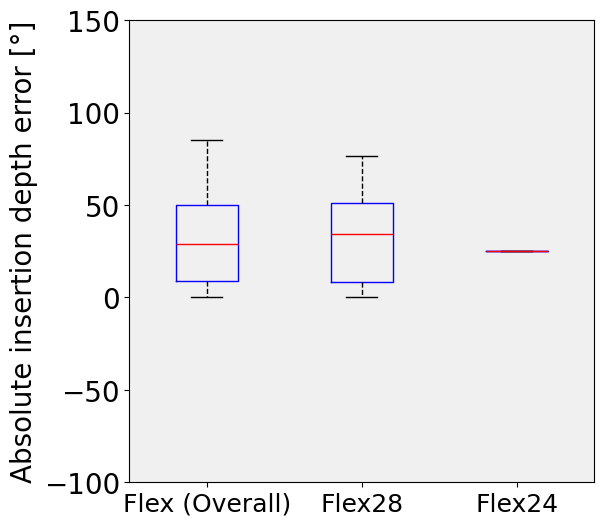

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- Filter by electrode type ---
absolute_diff_flex24 = absolute_diff[array_type == "Flex24"]
absolute_diff_flex28 = absolute_diff[array_type == "Flex28"]
absolute_diff_flex = absolute_diff[
    np.isin(array_type, ["Standard", "Flex24", "Flex28"])
]

# --- Combine data ---
data = [absolute_diff_flex, absolute_diff_flex28, absolute_diff_flex24]
labels = ["Flex (Overall)", "Flex28", "Flex24"]

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,6))

# Background
ax.set_facecolor('#f0f0f0')

box = ax.boxplot(
    data,
    widths=0.4,
    patch_artist=False,   # no fill, like your other plots
    boxprops=dict(color='blue'),
    medianprops=dict(color='red'),
    whiskerprops=dict(color='black', linestyle='--'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='black')
)

# Labels (removes the "1")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels, fontsize = 18)

# Y-axis symmetric like others
max_val = np.max(np.abs(absolute_diff))
ax.set_ylim(-100, 100)

#Set y-axis ticks to increments of 50
ax.set_yticks([-100, -50, 0, 50, 100, 150])
ax.tick_params(axis='y', labelsize=20)

# Axis label
ax.set_ylabel("Absolute insertion depth error [°]", fontsize = 20)

# Remove grid 
ax.grid(False)

plt.show()

In [24]:
print(len(absolute_diff_flex))
print(np.unique(array_type))

37
['CI522' 'Flex24' 'Flex28' 'HiFocus SlimJ' 'Standard']


In [13]:
error_all = (np.array(y_pred_all) - np.array(y_true_all))

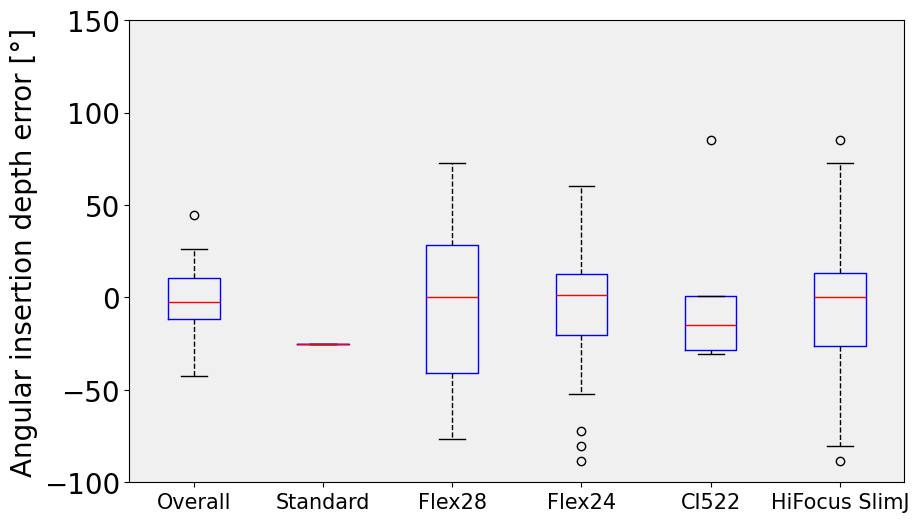

In [18]:
import numpy as np
import matplotlib.pyplot as plt

#This is for value for that are NOT absolute

err_CI522 = error_all[array_type == "CI522"]
err_Flex24 = error_all[array_type == "Flex24"]
err_Flex28 = error_all[array_type == "Flex28"]
err_HiFocus_SlimJ = error_all[array_type == "HiFocus SlimJ"]
err_Standard = error_all[array_type == "Standard"]

err_overall = error_all

# --- Unique container ---
boxplot_groups = [
    err_CI522,
    err_Flex24,
    err_Flex28,
    err_HiFocus_SlimJ,
    err_Standard,
    err_overall
]

labels = [
   "Overall",
    "Standard",
    "Flex28" ,
    "Flex24",
    "CI522",
    "HiFocus SlimJ"
    
]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,6))

ax.set_facecolor('#f0f0f0')

ax.boxplot(
    boxplot_groups,
    widths=0.4,
    patch_artist=False,
    boxprops=dict(color='blue'),
    medianprops=dict(color='red'),
    whiskerprops=dict(color='black', linestyle='--'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='black')
)

# X-axis
ax.set_xticks([1,2,3,4,5,6])
ax.set_xticklabels(labels, fontsize=15)

# KEEP your y-axis exactly the same
ax.set_ylim(-100, 100)
ax.set_yticks([-100, -50, 0, 50, 100, 150])
ax.tick_params(axis='y', labelsize=20)

# Label
ax.set_ylabel("Angular insertion depth error [°]", fontsize=20)

ax.grid(False)

plt.show()